In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [243]:
data =pd.read_csv("archive/diabetes_012_health_indicators_BRFSS2015.csv")
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [244]:
data["Diabetes_012"].value_counts(normalize=True)

Diabetes_012
0.0    0.842412
2.0    0.139333
1.0    0.018255
Name: proportion, dtype: float64

In [245]:
data.shape

(253680, 22)

In [246]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [247]:
X = data.drop("Diabetes_012", axis=1)
y = data["Diabetes_012"]

In [248]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [249]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((202944, 21), (50736, 21), (202944,), (50736,))

In [250]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [251]:
# Create the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(3, activation='softmax'))

c:\Users\DELL\Desktop\Master ISJ Data Science\Master 2\NLP\SN NLP\SN_NLP\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [252]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,555 (37.32 KB)

 Trainable params: 9,555 (37.32 KB)

 Non-trainable params: 0 (0.00 B)

In [253]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [254]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('diabete.keras', save_best_only=True, monitor='val_loss')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

In [255]:
from sklearn.utils import class_weight

# Calcul automatique des poids
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
dict_weights = dict(enumerate(weights))
dict_weights

{0: np.float64(0.395690270352476),
 1: np.float64(18.258569500674763),
 2: np.float64(2.392332991477172)}

In [256]:
diabete = model.fit(X_train_sc, y_train, validation_data=(X_test_sc, y_test), epochs=25, batch_size=32,class_weight=dict_weights,
                    callbacks=[early_stop, model_checkpoint, reduce_lr])

Epoch 1/25
6342/6342 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.6055 - loss: 0.9827 - val_accuracy: 0.6716 - val_loss: 0.8289 - learning_rate: 0.0010
Epoch 2/25
6342/6342 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.6205 - loss: 0.9624 - val_accuracy: 0.5792 - val_loss: 0.9522 - learning_rate: 0.0010
Epoch 3/25
6342/6342 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.6084 - loss: 0.9598 - val_accuracy: 0.5519 - val_loss: 0.9437 - learning_rate: 0.0010
Epoch 4/25
6342/6342 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.6019 - loss: 0.9582 - val_accuracy: 0.5933 - val_loss: 0.8993 - learning_rate: 0.0010
Epoch 5/25
6342/6342 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.6080 - loss: 0.9571 - val_accuracy: 0.6228 - val_loss: 0.9172 - learning_rate: 0.0010
Epoch 6/25
6342/6342 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.6137 - loss: 0.9547 - val_accuracy: 0.5898 - val_loss: 0.8923 - learning_rate: 0.0010


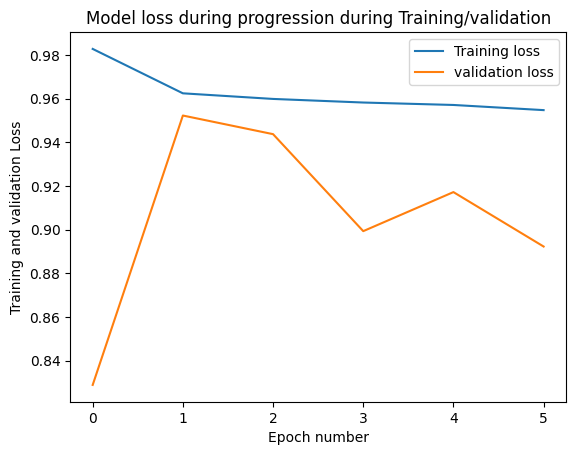

In [257]:
plt.plot(diabete.history['loss'],label='loss')
plt.plot(diabete.history['val_loss'],label='val_loss')
plt.title('Model loss during progression during Training/validation')
plt.ylabel('Training and validation Loss')
plt.xlabel('Epoch number')
plt.legend(['Training loss','validation loss'])
plt.show()

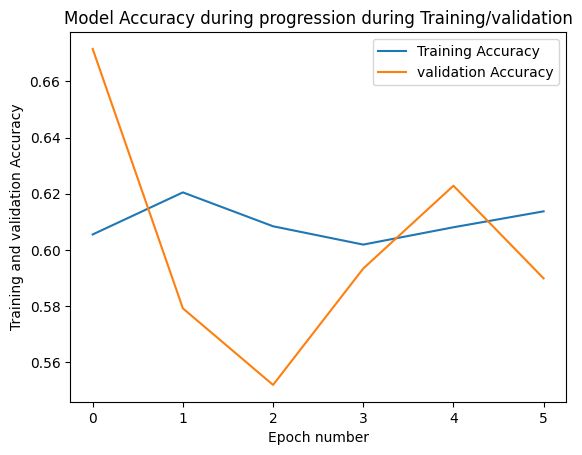

In [258]:
plt.plot(diabete.history['accuracy'],label='accuracy')
plt.plot(diabete.history['val_accuracy'],label='val_accuracy')
plt.title('Model Accuracy during progression during Training/validation')
plt.ylabel('Training and validation Accuracy')
plt.xlabel('Epoch number')
plt.legend(['Training Accuracy','validation Accuracy'])
plt.show()

In [259]:
loss, accuracy = model.evaluate(X_test_sc, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

1586/1586 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6716 - loss: 0.8289
Test Loss: 0.8289
Test Accuracy: 0.6716


1586/1586 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


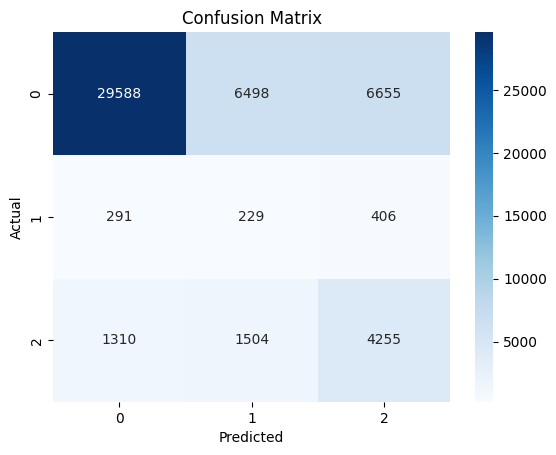


Rapport de classification:
              precision    recall  f1-score   support

         0.0       0.95      0.69      0.80     42741
         1.0       0.03      0.25      0.05       926
         2.0       0.38      0.60      0.46      7069

    accuracy                           0.67     50736
   macro avg       0.45      0.51      0.44     50736
weighted avg       0.85      0.67      0.74     50736



In [260]:
# Matrix de confusion pour classification multi-classes
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Prédiction pour multi-classes (argmax au lieu de > 0.5)
y_pred_proba = model.predict(X_test_sc)
y_pred = np.argmax(y_pred_proba, axis=1)


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Rapport de classification
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))

In [261]:
# Test de prédiction
predictions = model.predict(X_test_sc[:5])
# On prend l'indice de la probabilité la plus élevée
classes_predites = np.argmax(predictions, axis=1)

print("\nProbabilités par classe (Softmax) :")
print(predictions)
print("Classes finales prédites :", classes_predites)
print("Vraies classes :", y_test[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Probabilités par classe (Softmax) :
[[0.47860023 0.32643777 0.19496197]
 [0.5391881  0.30343866 0.15737334]
 [0.7180098  0.21465017 0.06734001]
 [0.33061972 0.37940788 0.28997234]
 [0.18039484 0.3911035  0.4285017 ]]
Classes finales prédites : [0 0 0 1 2]
Vraies classes : 167906    0.0
41549     0.0
42992     0.0
88678     0.0
64335     0.0
Name: Diabetes_012, dtype: float64
